In [1]:
!pip install kagglehub==1.0.0


   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/

In [2]:
import os

path = None

if os.path.exists("aca-butterflies"):
    path = "./aca-butterflies"
else:
    # login in a different cell to avoid a known kagglehub issue
    import kagglehub
    kagglehub.login()

In [3]:
if path is None:
    # do not forget to enter the Kaggle competition through the link in the project statement (section 4)
    path = kagglehub.competition_download('aca-tp-2')
    print("Path to dataset files:", path)

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.optim as optim

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [6]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [7]:
# load the data
img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


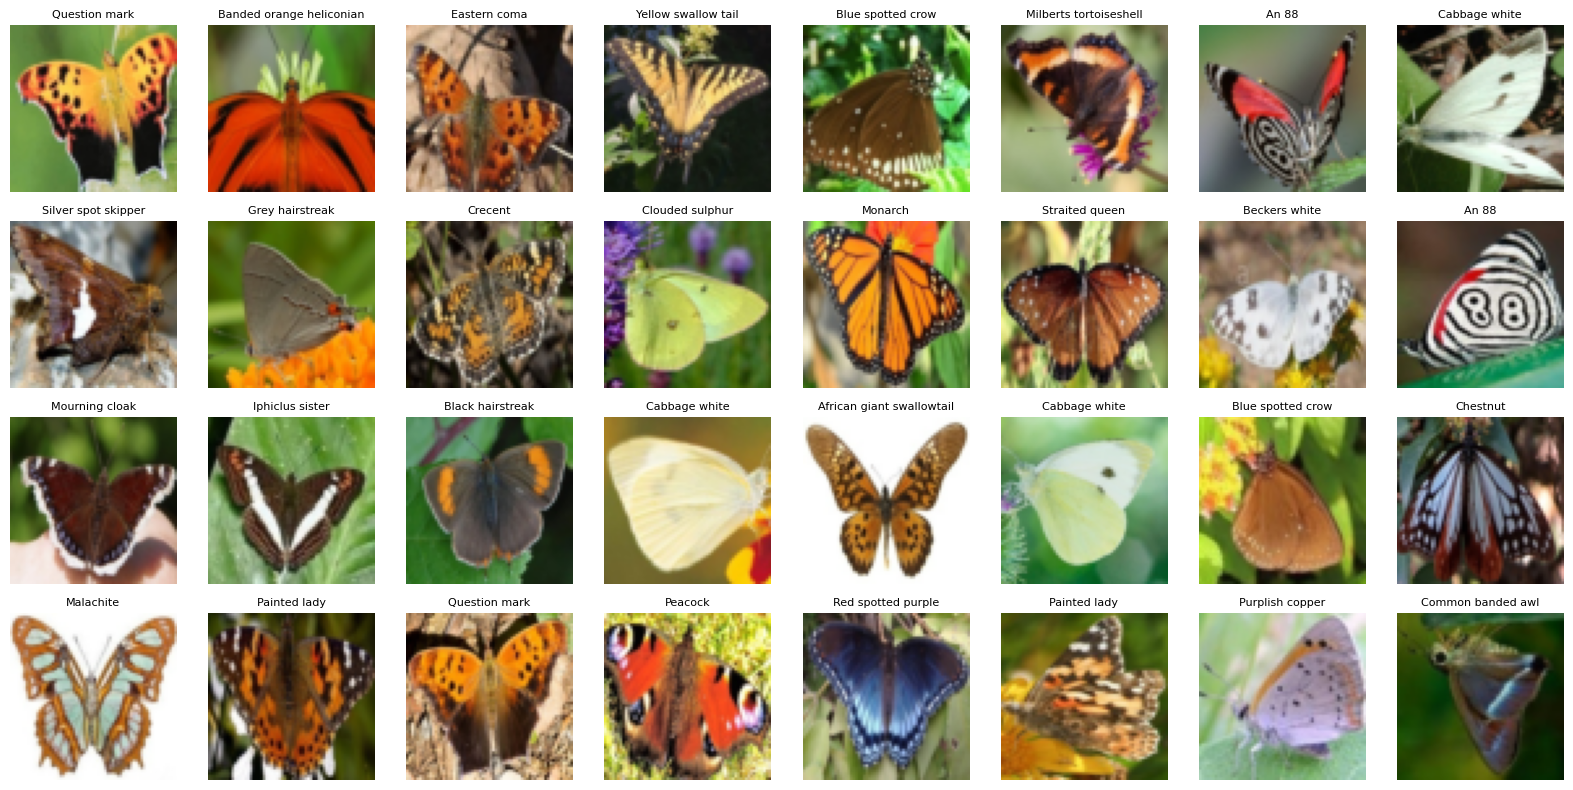

In [9]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Classifier

In [10]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )

        self.features = nn.Sequential(
            conv_block(3, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            *[layer for size in [256, 512, 1024]
            for layer in (nn.Linear(size, size*2), nn.ReLU(inplace=True), nn.Dropout(p=0.5))],
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [11]:
n_classes = len(dataset.classes)
model = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

## Train / Validation / Test Split
Stratified 70 / 15 / 15 split — `random_state=42` for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified 70/15/15 split — seed=42 (same as generative notebooks)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

train_set = ButterflyDataset(train_df, img_dir, transform=data_transform)
val_set   = ButterflyDataset(val_df,   img_dir, transform=data_transform)
test_set  = ButterflyDataset(test_df,  img_dir, transform=data_transform)

train_loader = data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = data.DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = data.DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

## Training Loop
GPU-aware training with validation and early stopping.

In [ ]:
import os

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

NUM_EPOCHS  = 50
ES_PATIENCE = 10

os.makedirs("saved_models", exist_ok=True)
model = model.to(device)

best_val_acc = 0.0
no_improve   = 0
train_losses, val_losses, val_accs = [], [], []

for epoch in range(NUM_EPOCHS):
    # ── Train ────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train = running_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validate ─────────────────────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds    = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    avg_val = val_loss / len(val_loader)
    acc     = correct / total
    val_losses.append(avg_val)
    val_accs.append(acc)

    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  "
          f"Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}  Val Acc: {acc:.4f}")

    # Save best checkpoint
    if acc > best_val_acc:
        best_val_acc = acc
        torch.save(model.state_dict(), "saved_models/baseline.pth")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= ES_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

In [ ]:
# Training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss Curves'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(val_accs)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load best checkpoint
model.load_state_dict(torch.load("saved_models/baseline.pth", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(labels.tolist())

acc      = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)

print("=== Baseline Test Results ===")
print(f"  Top-1 Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro F1       : {macro_f1:.4f}")
print()
print(classification_report(
    all_true, all_preds,
    target_names=test_set.classes,
    zero_division=0,
    digits=4,
))